Sequential baseline for 1k.txt: 53587.0 µs
Threads=2, Time=94536.0 µs
Threads=4, Time=56980.0 µs
Threads=6, Time=58114.0 µs
Threads=8, Time=50447.0 µs
Threads=10, Time=42096.0 µs
Threads=12, Time=40732.0 µs
Threads=14, Time=39053.0 µs
Threads=16, Time=37396.0 µs
Threads=18, Time=41490.0 µs
Threads=20, Time=37664.0 µs
Threads=22, Time=38643.0 µs
Threads=24, Time=40691.0 µs
Threads=26, Time=43353.0 µs
Threads=28, Time=43152.0 µs
Threads=30, Time=37235.0 µs
Threads=32, Time=40419.0 µs


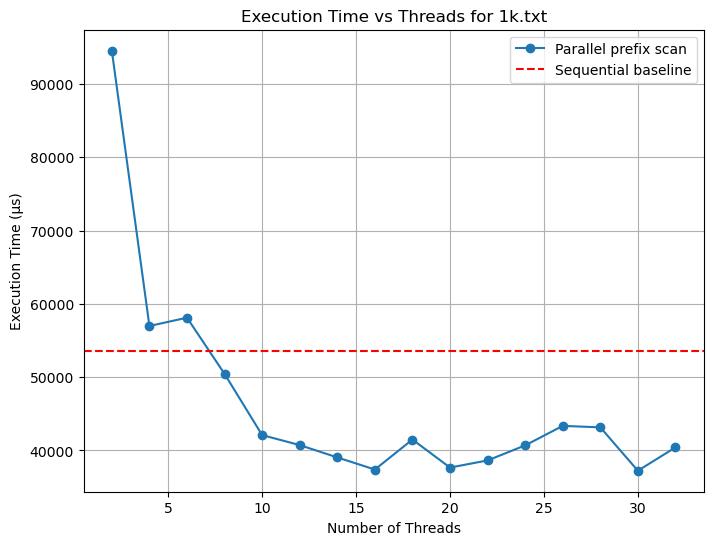

Sequential baseline for 8k.txt: 438110.0 µs
Threads=2, Time=702612.0 µs
Threads=4, Time=433208.0 µs
Threads=6, Time=330816.0 µs
Threads=8, Time=305078.0 µs
Threads=10, Time=263665.0 µs
Threads=12, Time=247949.0 µs
Threads=14, Time=232998.0 µs
Threads=16, Time=216403.0 µs
Threads=18, Time=207898.0 µs
Threads=20, Time=186794.0 µs
Threads=22, Time=199349.0 µs
Threads=24, Time=195641.0 µs
Threads=26, Time=196974.0 µs
Threads=28, Time=217520.0 µs
Threads=30, Time=192162.0 µs
Threads=32, Time=186862.0 µs


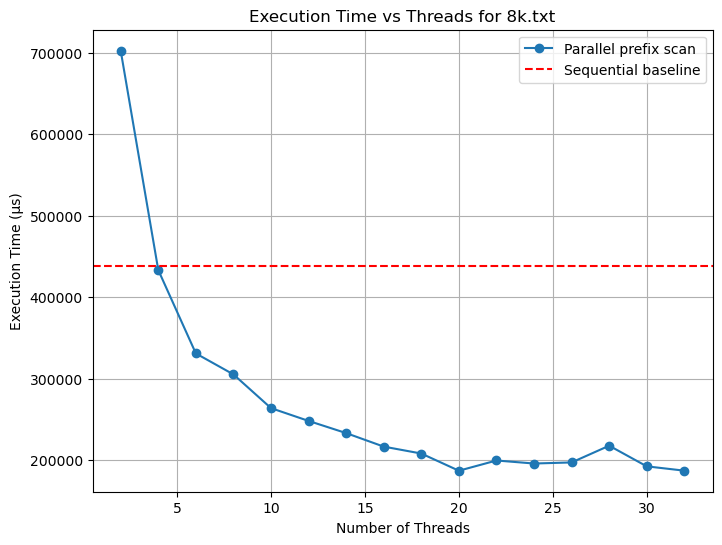

Sequential baseline for 16k.txt: 962652.0 µs
Threads=2, Time=1443461.0 µs
Threads=4, Time=778741.0 µs
Threads=6, Time=600287.0 µs
Threads=8, Time=524856.0 µs
Threads=10, Time=473914.0 µs
Threads=12, Time=430732.0 µs
Threads=14, Time=424068.0 µs
Threads=16, Time=405234.0 µs
Threads=18, Time=418898.0 µs
Threads=20, Time=401898.0 µs
Threads=22, Time=412299.0 µs
Threads=24, Time=412128.0 µs
Threads=26, Time=395469.0 µs
Threads=28, Time=372563.0 µs
Threads=30, Time=346646.0 µs
Threads=32, Time=375491.0 µs


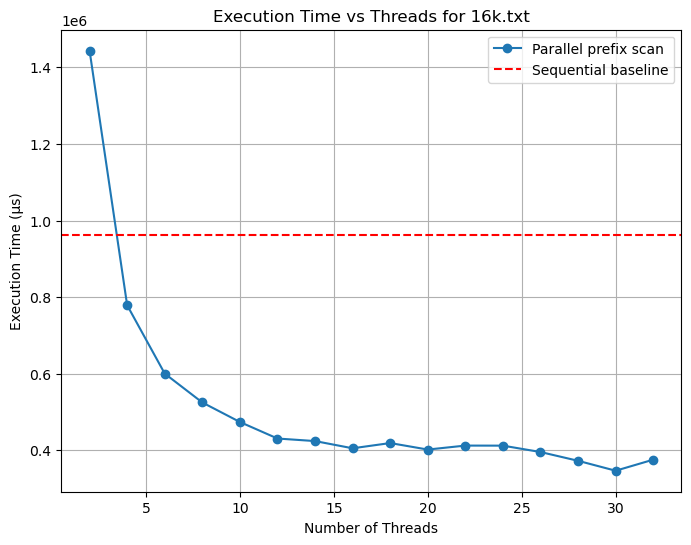

Sequential baseline for seq_64_test.txt: 3402.0 µs
Threads=2, Time=7461.0 µs
Threads=4, Time=6496.0 µs
Threads=6, Time=5669.0 µs
Threads=8, Time=6026.0 µs
Threads=10, Time=7038.0 µs
Threads=12, Time=7514.0 µs
Threads=14, Time=7511.0 µs
Threads=16, Time=8102.0 µs
Threads=18, Time=7490.0 µs
Threads=20, Time=9051.0 µs
Threads=22, Time=9382.0 µs
Threads=24, Time=8942.0 µs
Threads=26, Time=9804.0 µs
Threads=28, Time=9380.0 µs
Threads=30, Time=10245.0 µs
Threads=32, Time=10480.0 µs


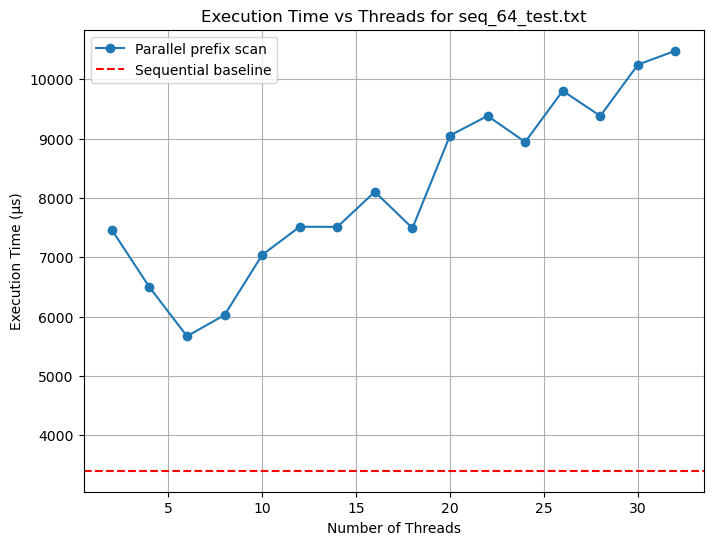

In [ ]:
import os
import re
from subprocess import check_output
import matplotlib.pyplot as plt

threads = list(range(2, 33, 2))  # 2 to 32, step 2
loops = 100000
inputs = ["1k.txt", "8k.txt", "16k.txt","seq_64_test.txt"]

results = {inp: {"threads": [], "times": []} for inp in inputs}

for inp in inputs:
    # Baseline sequential time 
    cmd = f"./bin/prefix_scan -o {inp}.txt -n 0 -i tests/{inp} -l {loops}"
    out = check_output(cmd, shell=True).decode("ascii")
    m = re.search(r"time: (.*)", out)
    seq_time = float(m.group(1)) if m else None

    for thr in threads:
        cmd = f"./bin/prefix_scan -o temp.txt -n {thr} -i tests/{inp} -l {loops}"
        out = check_output(cmd, shell=True).decode("ascii")
        m = re.search(r"time: (.*)", out)
        if m:
            t = float(m.group(1))
            results[inp]["threads"].append(thr)
            results[inp]["times"].append(t)
            print(f"Threads={thr}, Time={t} µs")

    #plotting
    plt.figure(figsize=(8,6))
    plt.plot(results[inp]["threads"], results[inp]["times"], marker="o", label="Parallel prefix scan")
    plt.axhline(y=seq_time, color="r", linestyle="--", label="Sequential baseline")

    plt.title(f"Execution Time vs Threads for {inp}")
    plt.xlabel("Number of Threads")
    plt.ylabel("Execution Time (µs)")
    plt.legend()
    plt.grid(True)
    plt.show()


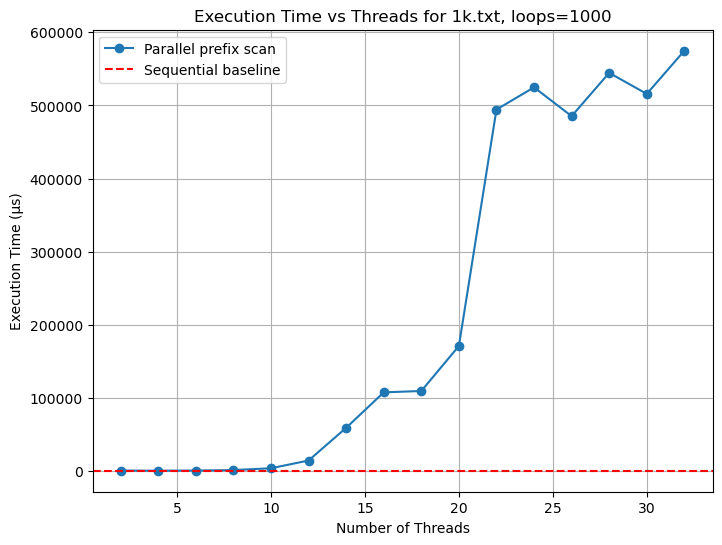

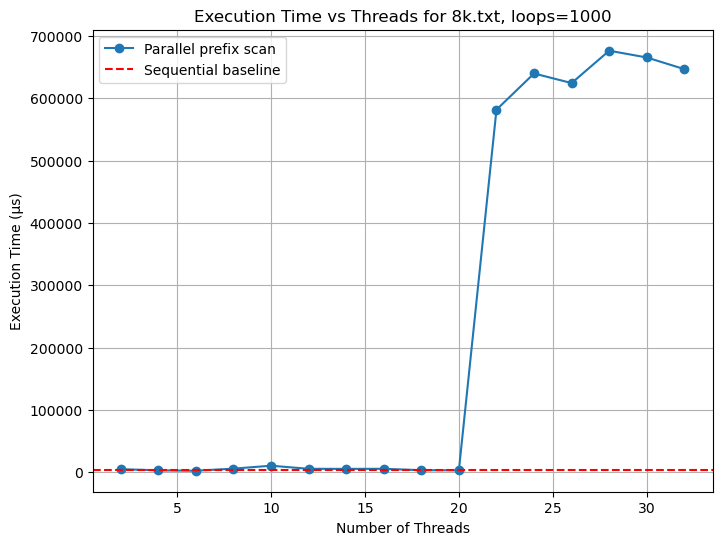

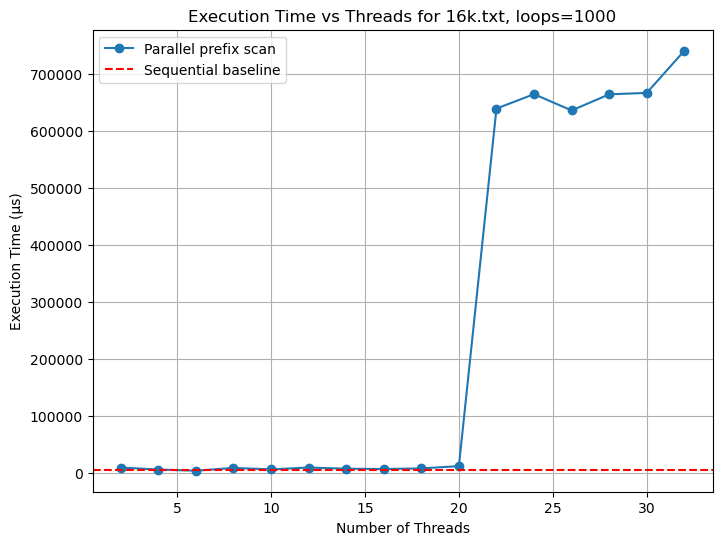

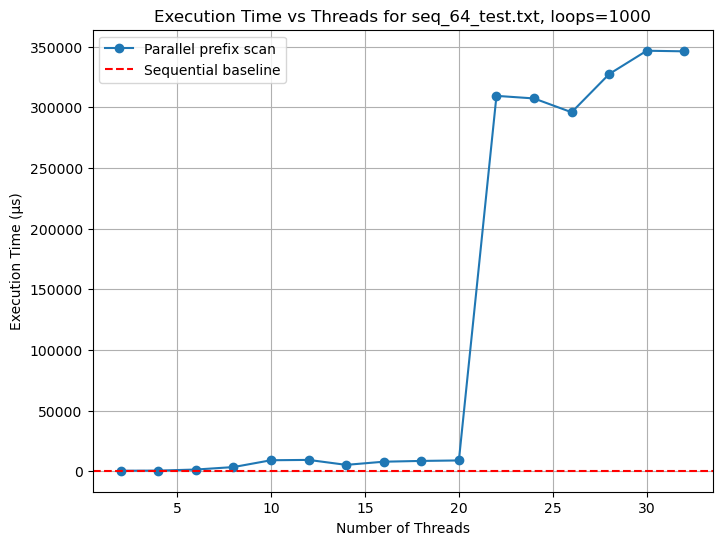

In [ ]:
#step2: Varying loops and plotting
#for step3, I just ran the make file with the custom spin-lock barrier and plotted the results
threads = list(range(2, 33, 2))  # 2 to 32, step 2
loop_list = [10000] 
inputs = ["1k.txt", "8k.txt", "16k.txt","seq_64_test.txt"]

for loops in loop_list:
    results = {inp: {"threads": [], "times": [], "seq_time": None} for inp in inputs}

    for inp in inputs:
        #baseline sequential time
        cmd = f"./bin/prefix_scan -o temp.txt -n 0 -i tests/{inp} -l {loops}"
        out = check_output(cmd, shell=True).decode("ascii")
        m = re.search(r"time: (.*)", out)
        seq_time = float(m.group(1)) if m else None
        results[inp]["seq_time"] = seq_time

        for thr in threads:
            cmd = f"./bin/prefix_scan -o temp.txt -n {thr} -i tests/{inp} -l {loops}"
            out = check_output(cmd, shell=True).decode("ascii")
            m = re.search(r"time: (.*)", out)
            if m:
                t = float(m.group(1))
                results[inp]["threads"].append(thr)
                results[inp]["times"].append(t)
                #print(f"[l={loops}] Threads={thr}, Time={t} µs")

        #plotting
        plt.figure(figsize=(8,6))
        plt.plot(results[inp]["threads"], results[inp]["times"], marker="o", label="Parallel prefix scan")
        plt.axhline(y=seq_time, color="r", linestyle="--", label="Sequential baseline")

        plt.title(f"Execution Time vs Threads for {inp}, loops={loops}")
        plt.xlabel("Number of Threads")
        plt.ylabel("Execution Time (µs)")
        plt.legend()
        plt.grid(True)
        plt.show()